# 🦠 Pipeline COVID-19 Argentina — Análisis a Escala con PySpark

## Sobre el dataset

Este proyecto trabaja con el dataset consolidado de casos de COVID-19 de la República
Argentina, publicado por el Ministerio de Salud. No es un dataset cualquiera: es el
**archivo CSV monolítico más pesado jamás publicado en el portal de Datos Abiertos
del país** — un único bloque continuo (sin particionar por año o mes, a diferencia
de otras bases estatales) que llegó a superar ampliamente el millón de filas límite
de Excel, obligando al propio Estado a publicar una guía oficial para abrir archivos
de gran escala con herramientas como Python o R.

La versión utilizada en este proyecto pesa **6,5 GB** y contiene **29.971.992 filas**
con 25 columnas — el registro completo, sin recortar, de todos los casos sospechosos,
confirmados y descartados notificados al Sistema Nacional de Vigilancia de la Salud
(SNVS) a lo largo de toda la pandemia.

## Por qué Spark, no pandas

Un archivo de este volumen es intratable con pandas en una notebook local sin
particionar manualmente en chunks (como en la primera versión de este proyecto).
Acá se reconstruye el pipeline completo usando **PySpark sobre Databricks**, con
arquitectura Medallion (Bronze → Silver → Gold) y Unity Catalog, para procesar
el dataset completo de forma distribuida, sin trucos de memoria.

## Bronze: Ingesta cruda

Cargamos el CSV original tal cual, sin inferir tipos de dato (`inferSchema = false`).
Todas las columnas se definen como `STRING` — Bronze es una copia fiel del dato crudo,
sin ninguna interpretación todavía. La tipificación real (enteros, fechas, booleanos)
se hace recién en la capa Silver, donde tenemos control explícito columna por columna.

Fuente: `Covid19Casos.csv` (29.971.992 filas, 25 columnas), subido al Volume
`workspace.covid.raw_data` vía Databricks SDK.

In [0]:
%sql
CREATE TABLE IF NOT EXISTS workspace.covid.bronze_casos (
  id_evento_caso STRING,
  sexo STRING,
  edad STRING,
  `edad_años_meses` STRING,
  residencia_pais_nombre STRING,
  residencia_provincia_nombre STRING,
  residencia_departamento_nombre STRING,
  carga_provincia_nombre STRING,
  fecha_inicio_sintomas STRING,
  fecha_apertura STRING,
  sepi_apertura STRING,
  fecha_internacion STRING,
  cuidado_intensivo STRING,
  fecha_cui_intensivo STRING,
  fallecido STRING,
  fecha_fallecimiento STRING,
  asistencia_respiratoria_mecanica STRING,
  carga_provincia_id STRING,
  origen_financiamiento STRING,
  clasificacion STRING,
  clasificacion_resumen STRING,
  residencia_provincia_id STRING,
  fecha_diagnostico STRING,
  residencia_departamento_id STRING,
  ultima_actualizacion STRING
)

### Carga incremental con COPY INTO

`COPY INTO` es idempotente por diseño: si se vuelve a correr, Databricks lleva registro
de qué archivos ya procesó y no los vuelve a cargar, evitando duplicados. Es la forma
recomendada de ingesta en Unity Catalog para este tipo de carga masiva desde un Volume.

In [0]:
%sql
COPY INTO workspace.covid.bronze_casos
FROM '/Volumes/workspace/covid/raw_data/Covid19Casos.csv'
FILEFORMAT = CSV
FORMAT_OPTIONS ('header' = 'true', 'inferSchema' = 'false')
COPY_OPTIONS ('mergeSchema' = 'false')

num_affected_rows,num_inserted_rows,num_skipped_corrupt_files
0,0,0


## EDA rápido sobre Bronze

Antes de definir el schema tipado de Silver, revisamos cada columna: cardinalidad
(valores distintos) y proporción de nulos. Esto nos permite detectar columnas
"basura" (por ejemplo, con un solo valor constante tipo "missing value" en el
100% de las filas) antes de invertir esfuerzo tipificándolas.

In [0]:
from pyspark.sql.functions import col, count, when

df_bronze = spark.table("workspace.covid.bronze_casos")
total_rows = df_bronze.count()

print(f"Total de filas: {total_rows:,}\n")

for column in df_bronze.columns:
    distinct_count = df_bronze.select(column).distinct().count()
    null_count = df_bronze.filter(
        col(column).isNull() | (col(column) == "")
    ).count()
    null_pct = (null_count / total_rows) * 100

    print(f"{column:35s} | valores distintos: {distinct_count:>10,} | nulos/vacíos: {null_count:>10,} ({null_pct:5.1f}%)")

Total de filas: 29,971,992

id_evento_caso                      | valores distintos: 29,965,594 | nulos/vacíos:          0 (  0.0%)
sexo                                | valores distintos:          3 | nulos/vacíos:          0 (  0.0%)
edad                                | valores distintos:        150 | nulos/vacíos:      8,531 (  0.0%)
edad_años_meses                     | valores distintos:          2 | nulos/vacíos:          0 (  0.0%)
residencia_pais_nombre              | valores distintos:        118 | nulos/vacíos:          0 (  0.0%)
residencia_provincia_nombre         | valores distintos:         25 | nulos/vacíos:          0 (  0.0%)
residencia_departamento_nombre      | valores distintos:        447 | nulos/vacíos:          0 (  0.0%)
carga_provincia_nombre              | valores distintos:         25 | nulos/vacíos:          0 (  0.0%)
fecha_inicio_sintomas               | valores distintos:        887 | nulos/vacíos: 21,292,773 ( 71.0%)
fecha_apertura                      

In [0]:
from pyspark.sql.functions import col

columnas_categoricas = [
    "sexo",
    "edad_años_meses",
    "cuidado_intensivo",
    "fallecido",
    "asistencia_respiratoria_mecanica",
    "origen_financiamiento",
    "clasificacion_resumen"
]

for c in columnas_categoricas:
    print(f"\n===== {c} =====")
    (
        df_bronze
        .groupBy(c)
        .count()
        .orderBy(col("count").desc())
        .show(truncate=False)
    )


===== sexo =====
+----+--------+
|sexo|count   |
+----+--------+
|F   |15842503|
|M   |13968570|
|NR  |160919  |
+----+--------+


===== edad_años_meses =====
+---------------+--------+
|edad_años_meses|count   |
+---------------+--------+
|Años           |29931630|
|Meses          |40362   |
+---------------+--------+


===== cuidado_intensivo =====
+-----------------+--------+
|cuidado_intensivo|count   |
+-----------------+--------+
|NO               |29883932|
|SI               |88060   |
+-----------------+--------+


===== fallecido =====
+---------+--------+
|fallecido|count   |
+---------+--------+
|NO       |29818971|
|SI       |153021  |
+---------+--------+


===== asistencia_respiratoria_mecanica =====
+--------------------------------+--------+
|asistencia_respiratoria_mecanica|count   |
+--------------------------------+--------+
|NO                              |29931499|
|SI                              |40493   |
+--------------------------------+--------+


===== ori

## Silver: Limpieza y tipado

Se aplican las siguientes transformaciones sobre Bronze:

- **Fechas** (`fecha_inicio_sintomas`, `fecha_apertura`, `fecha_internacion`, `fecha_cui_intensivo`,
  `fecha_fallecimiento`, `fecha_diagnostico`): convertidas de STRING a DATE (formato ISO `yyyy-MM-dd`).
- **Booleanas** (`cuidado_intensivo`, `fallecido`, `asistencia_respiratoria_mecanica`): "SI"/"NO" → BOOLEAN.
- **`edad`**: normalizada a `edad_anios` (INT). Los valores del grupo "Meses" se mantienen en 0
  (bebé menor de 1 año). Los valores negativos, mayores a 120, o nulos dentro del grupo "Años"
  se convierten a NULL (0.037% de los casos — ver EDA previo).
- **`origen_financiamiento`**: el placeholder `*sin dato*` se convierte a NULL.
- **`sexo`**: se mantiene "NR" como categoría propia (no se nulea) — representa una respuesta
  real de "no registrado", distinta de un fallo de carga.
- Columnas de solo metadato del archivo (`ultima_actualizacion`) se descartan, ya que son
  constantes y no aportan información analítica.

In [0]:
from pyspark.sql.functions import col, when, to_date

df_silver = (
    df_bronze
    .withColumn(
        "edad_anios",
        when(col("edad_años_meses") == "Meses", 0)
        .when(
            (col("edad_años_meses") == "Años")
            & col("edad").cast("int").isNotNull()
            & (col("edad").cast("int") >= 0)
            & (col("edad").cast("int") <= 120),
            col("edad").cast("int")
        )
        .otherwise(None)
    )
    .withColumn("fecha_inicio_sintomas", to_date(col("fecha_inicio_sintomas"), "yyyy-MM-dd"))
    .withColumn("fecha_apertura", to_date(col("fecha_apertura"), "yyyy-MM-dd"))
    .withColumn("fecha_internacion", to_date(col("fecha_internacion"), "yyyy-MM-dd"))
    .withColumn("fecha_cui_intensivo", to_date(col("fecha_cui_intensivo"), "yyyy-MM-dd"))
    .withColumn("fecha_fallecimiento", to_date(col("fecha_fallecimiento"), "yyyy-MM-dd"))
    .withColumn("fecha_diagnostico", to_date(col("fecha_diagnostico"), "yyyy-MM-dd"))
    .withColumn("cuidado_intensivo", when(col("cuidado_intensivo") == "SI", True).otherwise(False))
    .withColumn("fallecido", when(col("fallecido") == "SI", True).otherwise(False))
    .withColumn(
        "asistencia_respiratoria_mecanica",
        when(col("asistencia_respiratoria_mecanica") == "SI", True).otherwise(False)
    )
    .withColumn(
        "origen_financiamiento",
        when(col("origen_financiamiento") == "*sin dato*", None).otherwise(col("origen_financiamiento"))
    )
    .drop("edad", "edad_años_meses", "ultima_actualizacion")
)

(
    df_silver.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable("workspace.covid.silver_casos")
)

print("Silver creada con éxito.")
print(f"Filas: {spark.table('workspace.covid.silver_casos').count():,}")

Silver creada con éxito.
Filas: 29,971,992


### Deduplicación de id_evento_caso

Se detectaron 6.398 id_evento_caso con exactamente 2 filas idénticas en todas las
columnas excepto `origen_financiamiento` (Público vs. Privado) — probablemente el
mismo evento reportado por dos subsistemas de cobertura. Se conserva una sola fila
por id_evento_caso (criterio determinístico: se prioriza "Público" cuando ambas
existen, dado que es el valor mayoritario en el dataset completo).

In [0]:
from pyspark.sql import Window
from pyspark.sql.functions import row_number, when

window_dedup = Window.partitionBy("id_evento_caso").orderBy(
    when(col("origen_financiamiento") == "Público", 0).otherwise(1)
)

df_silver_dedup = (
    df_silver
    .withColumn("rn", row_number().over(window_dedup))
    .filter(col("rn") == 1)
    .drop("rn")
)

print(f"Filas antes: {df_silver.count():,}")
print(f"Filas después de deduplicar: {df_silver_dedup.count():,}")

(
    df_silver_dedup.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable("workspace.covid.silver_casos")
)

print("Silver actualizada sin duplicados.")

Filas antes: 29,971,992
Filas después de deduplicar: 29,965,594
Silver actualizada sin duplicados.


### Renombrado de columnas para legibilidad

Se renombran columnas técnicas a nombres más claros para analistas de negocio,
siguiendo el criterio de que Silver debe representar el dominio de forma legible,
no solo técnicamente correcta.

In [0]:
df_silver_final = (
    df_silver_dedup
    .withColumnRenamed("id_evento_caso", "id_caso")
    .withColumnRenamed("residencia_provincia_nombre", "provincia")
    .withColumnRenamed("residencia_departamento_nombre", "departamento")
    .withColumnRenamed("residencia_pais_nombre", "pais")
    .withColumnRenamed("asistencia_respiratoria_mecanica", "requirio_arm")
    .withColumnRenamed("cuidado_intensivo", "requirio_uti")
    .withColumnRenamed("clasificacion", "clasificacion_detalle")
    .withColumnRenamed("clasificacion_resumen", "clasificacion")
)

(
    df_silver_final.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable("workspace.covid.silver_casos")
)

print("Silver renombrada y guardada.")
print(f"Columnas finales: {df_silver_final.columns}")

Silver renombrada y guardada.
Columnas finales: ['id_caso', 'sexo', 'pais', 'provincia', 'departamento', 'carga_provincia_nombre', 'fecha_inicio_sintomas', 'fecha_apertura', 'sepi_apertura', 'fecha_internacion', 'requirio_uti', 'fecha_cui_intensivo', 'fallecido', 'fecha_fallecimiento', 'requirio_arm', 'carga_provincia_id', 'origen_financiamiento', 'clasificacion_detalle', 'clasificacion', 'residencia_provincia_id', 'fecha_diagnostico', 'residencia_departamento_id', 'edad_anios']


## Gold: Dimensiones geográficas

`dim_provincia` usa `provincia_id` (código INDEC) como clave — es único a nivel
nacional, sin ambigüedad.

`dim_departamento` **no puede** usar el código INDEC de departamento como parte de
su clave: se detectaron 23 combinaciones de (departamento_id, provincia_id) que
mapean a más de un nombre de departamento distinto (ej: código "035" en provincia "06"
representa a la vez "Avellaneda", "General Pedernera" y "Junín" — departamentos sin
relación entre sí). Esto afecta 1.293.221 filas (4.3% del dataset) y es un problema
real del dato de origen, no de formato.

Se resuelve usando **(`departamento_nombre`, `provincia_id`)** como clave de
`dim_departamento`, con `departamento_sk` como clave sustituta para los joins.
El código INDEC original se conserva como columna informativa, pero no se usa
para el join.

In [0]:
from pyspark.sql.functions import col, monotonically_increasing_id, first

df_silver = spark.table("workspace.covid.silver_casos")

dim_departamento = (
    df_silver
    .filter(col("departamento").isNotNull())
    .groupBy(
        col("departamento").alias("departamento_nombre"),
        col("residencia_provincia_id").alias("provincia_id")
    )
    .agg(
        first("residencia_departamento_id", ignorenulls=True).alias("departamento_id_original")
    )
    .withColumn("departamento_sk", monotonically_increasing_id())
)

dim_departamento.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("workspace.covid.dim_departamento")

print(f"dim_departamento: {dim_departamento.count()} filas")

chequeo = (
    dim_departamento.groupBy("departamento_nombre", "provincia_id")
    .count()
    .filter(col("count") > 1)
)
print(f"Combinaciones (nombre, provincia) duplicadas: {chequeo.count()}")

dim_departamento: 608 filas
Combinaciones (nombre, provincia) duplicadas: 0


## Gold: fact_casos

Tabla de hechos a nivel de caso individual. Referencia a las dimensiones por
`provincia_id` (clave nacional única) y `departamento_sk` (clave sustituta,
dado que el código INDEC de departamento se repite entre provincias).

Se agregan columnas derivadas de demora (en días) entre eventos clínicos clave:
inicio de síntomas → diagnóstico, internación, UTI, fallecimiento, y notificación
administrativa (apertura del caso).

In [0]:
from pyspark.sql.functions import col, datediff

df_silver = spark.table("workspace.covid.silver_casos")
dim_departamento = spark.table("workspace.covid.dim_departamento")

fact_casos = (
    df_silver
    .join(
        dim_departamento.select("departamento_nombre", "provincia_id", "departamento_sk"),
        (df_silver["departamento"] == dim_departamento["departamento_nombre"])
        & (df_silver["residencia_provincia_id"] == dim_departamento["provincia_id"]),
        "left"
    )
    .select(
        col("id_caso"),
        col("sexo"),
        col("pais"),
        col("residencia_provincia_id").alias("provincia_id"),
        col("departamento_sk"),
        col("edad_anios"),
        col("clasificacion"),
        col("origen_financiamiento"),
        col("requirio_uti"),
        col("requirio_arm"),
        col("fallecido"),
        col("fecha_inicio_sintomas"),
        col("fecha_apertura"),
        col("fecha_diagnostico"),
        col("fecha_internacion"),
        col("fecha_cui_intensivo"),
        col("fecha_fallecimiento"),
        datediff(col("fecha_apertura"), col("fecha_inicio_sintomas")).alias("dias_a_notificacion"),
        datediff(col("fecha_diagnostico"), col("fecha_inicio_sintomas")).alias("dias_a_diagnostico"),
        datediff(col("fecha_internacion"), col("fecha_inicio_sintomas")).alias("dias_a_internacion"),
        datediff(col("fecha_cui_intensivo"), col("fecha_inicio_sintomas")).alias("dias_a_uti"),
        datediff(col("fecha_fallecimiento"), col("fecha_inicio_sintomas")).alias("dias_a_fallecimiento"),
    )
)

fact_casos.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("workspace.covid.fact_casos")

print(f"fact_casos: {fact_casos.count():,} filas")

fact_casos: 29,965,594 filas


### Verificación de nulos en fact_casos

Chequeo de calidad post-join: confirmar que las columnas clave (especialmente
`departamento_sk`, resultado del join con la dimensión) no tengan una proporción
inesperada de nulos.

In [0]:
from pyspark.sql.functions import col

fact_casos = spark.table("workspace.covid.fact_casos")
total = fact_casos.count()

for column in fact_casos.columns:
    nulls = fact_casos.filter(col(column).isNull()).count()
    if nulls > 0:
        print(f"{column:25s} | nulos: {nulls:>10,} ({nulls/total*100:5.1f}%)")

edad_anios                | nulos:     11,231 (  0.0%)
origen_financiamiento     | nulos:    201,126 (  0.7%)
fecha_inicio_sintomas     | nulos: 21,287,032 ( 71.0%)
fecha_apertura            | nulos:          4 (  0.0%)
fecha_diagnostico         | nulos:  1,711,317 (  5.7%)
fecha_internacion         | nulos: 29,461,265 ( 98.3%)
fecha_cui_intensivo       | nulos: 29,877,098 ( 99.7%)
fecha_fallecimiento       | nulos: 29,812,585 ( 99.5%)
dias_a_notificacion       | nulos: 21,287,033 ( 71.0%)
dias_a_diagnostico        | nulos: 22,239,500 ( 74.2%)
dias_a_internacion        | nulos: 29,526,422 ( 98.5%)
dias_a_uti                | nulos: 29,884,201 ( 99.7%)
dias_a_fallecimiento      | nulos: 29,829,627 ( 99.5%)


## Gold: gold_mortalidad_por_sexo

Tasa de mortalidad y severidad (UTI/ARM) comparada por sexo, solo sobre casos
confirmados (el resto no tiene sentido para medir letalidad real).

In [0]:
from pyspark.sql.functions import col, count, sum as spark_sum, round as spark_round

fact_casos = spark.table("workspace.covid.fact_casos")

gold_mortalidad_por_sexo = (
    fact_casos
    .filter(col("clasificacion") == "Confirmado")
    .groupBy("sexo")
    .agg(
        count("*").alias("total_casos"),
        spark_sum(col("fallecido").cast("int")).alias("total_fallecidos"),
        spark_sum(col("requirio_uti").cast("int")).alias("total_uti"),
        spark_sum(col("requirio_arm").cast("int")).alias("total_arm"),
    )
    .withColumn("tasa_mortalidad_pct", spark_round(col("total_fallecidos") / col("total_casos") * 100, 2))
    .withColumn("tasa_uti_pct", spark_round(col("total_uti") / col("total_casos") * 100, 2))
    .withColumn("tasa_arm_pct", spark_round(col("total_arm") / col("total_casos") * 100, 2))
)

gold_mortalidad_por_sexo.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("workspace.covid.gold_mortalidad_por_sexo")

gold_mortalidad_por_sexo.orderBy(col("total_casos").desc()).show(truncate=False)

+----+-----------+----------------+---------+---------+-------------------+------------+------------+
|sexo|total_casos|total_fallecidos|total_uti|total_arm|tasa_mortalidad_pct|tasa_uti_pct|tasa_arm_pct|
+----+-----------+----------------+---------+---------+-------------------+------------+------------+
|F   |4778680    |53927           |18867    |10253    |1.13               |0.39        |0.21        |
|M   |4417811    |72793           |29851    |17732    |1.65               |0.68        |0.4         |
|NR  |47772      |2249            |713      |327      |4.71               |1.49        |0.68        |
+----+-----------+----------------+---------+---------+-------------------+------------+------------+



## Gold: gold_casos_por_pais

Cantidad de casos registrados por país de residencia, para identificar el volumen
de casos correspondientes a residentes extranjeros vs. Argentina.

In [0]:
gold_casos_por_pais = (
    fact_casos
    .groupBy("pais")
    .agg(
        count("*").alias("total_casos"),
        spark_sum(col("fallecido").cast("int")).alias("total_fallecidos"),
    )
    .withColumn(
        "pct_del_total",
        spark_round(col("total_casos") / fact_casos.count() * 100, 4)
    )
)

gold_casos_por_pais.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("workspace.covid.gold_casos_por_pais")

gold_casos_por_pais.orderBy(col("total_casos").desc()).show(120, truncate=False)

+--------------------------------+-----------+----------------+-------------+
|pais                            |total_casos|total_fallecidos|pct_del_total|
+--------------------------------+-----------+----------------+-------------+
|Argentina                       |28570690   |143897          |95.345       |
|SIN ESPECIFICAR                 |1370125    |9055            |4.5723       |
|Chile                           |5515       |12              |0.0184       |
|Brasil                          |5216       |2               |0.0174       |
|Paraguay                        |2224       |19              |0.0074       |
|Bolivia                         |2181       |12              |0.0073       |
|EE.UU.                          |2123       |1               |0.0071       |
|Uruguay                         |1504       |6               |0.005        |
|Perú                            |871        |1               |0.0029       |
|España                          |781        |0               |0

## Gold: gold_kpis_generales

Métricas resumen de una sola fila — el panorama general del dataset completo,
sin ningún cruce por dimensión. Sirve como "tarjetas" (cards) en el dashboard final.

In [0]:
from pyspark.sql.functions import col, count, sum as spark_sum, avg, round as spark_round, lit

fact_casos = spark.table("workspace.covid.fact_casos")

total_casos = fact_casos.count()
confirmados = fact_casos.filter(col("clasificacion") == "Confirmado")
total_confirmados = confirmados.count()

gold_kpis_generales = spark.createDataFrame([{
    "total_casos_notificados": total_casos,
    "total_confirmados": total_confirmados,
    "total_descartados": fact_casos.filter(col("clasificacion") == "Descartado").count(),
    "total_fallecidos": confirmados.filter(col("fallecido")).count(),
    "total_requirio_uti": confirmados.filter(col("requirio_uti")).count(),
    "total_requirio_arm": confirmados.filter(col("requirio_arm")).count(),
    "tasa_mortalidad_pct": round(confirmados.filter(col("fallecido")).count() / total_confirmados * 100, 2),
    "promedio_dias_a_diagnostico": confirmados.agg(avg("dias_a_diagnostico")).collect()[0][0],
    "promedio_dias_a_fallecimiento": confirmados.agg(avg("dias_a_fallecimiento")).collect()[0][0],
}])

gold_kpis_generales.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("workspace.covid.gold_kpis_generales")

gold_kpis_generales.show(truncate=False)

+---------------------------+-----------------------------+-------------------+-----------------------+-----------------+-----------------+----------------+------------------+------------------+
|promedio_dias_a_diagnostico|promedio_dias_a_fallecimiento|tasa_mortalidad_pct|total_casos_notificados|total_confirmados|total_descartados|total_fallecidos|total_requirio_arm|total_requirio_uti|
+---------------------------+-----------------------------+-------------------+-----------------------+-----------------+-----------------+----------------+------------------+------------------+
|5.504292508234743          |16.80257887045474            |1.4                |29965594               |9244263          |19804638         |128969          |28312             |49431             |
+---------------------------+-----------------------------+-------------------+-----------------------+-----------------+-----------------+----------------+------------------+------------------+



## Gold: gold_casos_por_dia

Serie temporal de casos confirmados por fecha de inicio de síntomas — la curva
epidemiológica clásica.

In [0]:
gold_casos_por_dia = (
    fact_casos
    .filter(col("clasificacion") == "Confirmado")
    .filter(col("fecha_inicio_sintomas").isNotNull())
    .groupBy("fecha_inicio_sintomas")
    .agg(
        count("*").alias("total_casos"),
        spark_sum(col("fallecido").cast("int")).alias("total_fallecidos"),
        spark_sum(col("requirio_uti").cast("int")).alias("total_uti"),
    )
    .orderBy("fecha_inicio_sintomas")
)

gold_casos_por_dia.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("workspace.covid.gold_casos_por_dia")

print(f"Días con datos: {gold_casos_por_dia.count():,}")

Días con datos: 886


## Gold: gold_resumen_provincia

Métricas de mortalidad y severidad por provincia, sobre casos confirmados.

In [0]:
dim_provincia = spark.table("workspace.covid.dim_provincia")

gold_resumen_provincia = (
    fact_casos
    .filter(col("clasificacion") == "Confirmado")
    .join(dim_provincia, fact_casos["provincia_id"] == dim_provincia["provincia_id"], "left")
    .groupBy(dim_provincia["provincia_nombre"])
    .agg(
        count("*").alias("total_casos"),
        spark_sum(col("fallecido").cast("int")).alias("total_fallecidos"),
        spark_sum(col("requirio_uti").cast("int")).alias("total_uti"),
        spark_sum(col("requirio_arm").cast("int")).alias("total_arm"),
        spark_round(avg("dias_a_diagnostico"), 1).alias("promedio_dias_diagnostico"),
    )
    .withColumn("tasa_mortalidad_pct", spark_round(col("total_fallecidos") / col("total_casos") * 100, 2))
)

gold_resumen_provincia.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("workspace.covid.gold_resumen_provincia")

gold_resumen_provincia.orderBy(col("total_casos").desc()).show(25, truncate=False)

+-------------------+-----------+----------------+---------+---------+-------------------------+-------------------+
|provincia_nombre   |total_casos|total_fallecidos|total_uti|total_arm|promedio_dias_diagnostico|tasa_mortalidad_pct|
+-------------------+-----------+----------------+---------+---------+-------------------------+-------------------+
|Buenos Aires       |3584051    |60069           |15381    |8393     |6.3                      |1.68               |
|CABA               |1073757    |12603           |6312     |3844     |5.5                      |1.17               |
|Córdoba            |983041     |7861            |5840     |2464     |3.3                      |0.8                |
|Santa Fe           |741693     |9396            |4131     |2424     |5.0                      |1.27               |
|Tucumán            |338802     |3644            |662      |368      |4.8                      |1.08               |
|Mendoza            |271439     |4952            |1371     |910 

## Gold: gold_mortalidad_por_edad

Letalidad y severidad por franja etaria — la curva clásica que muestra cómo
aumenta el riesgo con la edad.

In [0]:
from pyspark.sql.functions import when as spark_when

gold_mortalidad_por_edad = (
    fact_casos
    .filter(col("clasificacion") == "Confirmado")
    .filter(col("edad_anios").isNotNull())
    .withColumn(
        "franja_etaria",
        spark_when(col("edad_anios") < 10, "0-9")
        .when(col("edad_anios") < 20, "10-19")
        .when(col("edad_anios") < 30, "20-29")
        .when(col("edad_anios") < 40, "30-39")
        .when(col("edad_anios") < 50, "40-49")
        .when(col("edad_anios") < 60, "50-59")
        .when(col("edad_anios") < 70, "60-69")
        .when(col("edad_anios") < 80, "70-79")
        .otherwise("80+")
    )
    .groupBy("franja_etaria")
    .agg(
        count("*").alias("total_casos"),
        spark_sum(col("fallecido").cast("int")).alias("total_fallecidos"),
        spark_sum(col("requirio_uti").cast("int")).alias("total_uti"),
    )
    .withColumn("tasa_mortalidad_pct", spark_round(col("total_fallecidos") / col("total_casos") * 100, 2))
    .orderBy("franja_etaria")
)

gold_mortalidad_por_edad.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("workspace.covid.gold_mortalidad_por_edad")

gold_mortalidad_por_edad.show(truncate=False)

+-------------+-----------+----------------+---------+-------------------+
|franja_etaria|total_casos|total_fallecidos|total_uti|tasa_mortalidad_pct|
+-------------+-----------+----------------+---------+-------------------+
|0-9          |226668     |198             |569      |0.09               |
|10-19        |678572     |202             |330      |0.03               |
|20-29        |1956597    |902             |1089     |0.05               |
|30-39        |2155568    |2641            |2570     |0.12               |
|40-49        |1777064    |7030            |5279     |0.4                |
|50-59        |1170203    |15090           |9057     |1.29               |
|60-69        |708541     |27053           |12227    |3.82               |
|70-79        |369057     |34113           |11036    |9.24               |
|80+          |199316     |41655           |7258     |20.9               |
+-------------+-----------+----------------+---------+-------------------+



## Gold: gold_demoras_sistema_salud

Promedio de días de demora (notificación, diagnóstico, internación) por provincia
— indicador de capacidad de respuesta del sistema sanitario.

In [0]:
gold_demoras_sistema_salud = (
    fact_casos
    .filter(col("clasificacion") == "Confirmado")
    .join(dim_provincia, fact_casos["provincia_id"] == dim_provincia["provincia_id"], "left")
    .groupBy(dim_provincia["provincia_nombre"])
    .agg(
        spark_round(avg("dias_a_notificacion"), 1).alias("promedio_dias_notificacion"),
        spark_round(avg("dias_a_diagnostico"), 1).alias("promedio_dias_diagnostico"),
        spark_round(avg("dias_a_internacion"), 1).alias("promedio_dias_internacion"),
    )
    .orderBy("provincia_nombre")
)

gold_demoras_sistema_salud.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("workspace.covid.gold_demoras_sistema_salud")

gold_demoras_sistema_salud.show(25, truncate=False)

+-------------------+--------------------------+-------------------------+-------------------------+
|provincia_nombre   |promedio_dias_notificacion|promedio_dias_diagnostico|promedio_dias_internacion|
+-------------------+--------------------------+-------------------------+-------------------------+
|Buenos Aires       |5.3                       |6.3                      |5.2                      |
|CABA               |0.6                       |5.5                      |4.8                      |
|Catamarca          |-1.9                      |10.5                     |8.3                      |
|Chaco              |5.2                       |4.1                      |5.3                      |
|Chubut             |20.5                      |6.6                      |6.6                      |
|Corrientes         |8.4                       |3.8                      |4.5                      |
|Córdoba            |4.4                       |3.3                      |5.6              

## Gold: gold_publico_vs_privado

Comparación de severidad y mortalidad según origen de financiamiento.

In [0]:
gold_publico_vs_privado = (
    fact_casos
    .filter(col("clasificacion") == "Confirmado")
    .filter(col("origen_financiamiento").isNotNull())
    .groupBy("origen_financiamiento")
    .agg(
        count("*").alias("total_casos"),
        spark_sum(col("fallecido").cast("int")).alias("total_fallecidos"),
        spark_sum(col("requirio_uti").cast("int")).alias("total_uti"),
    )
    .withColumn("tasa_mortalidad_pct", spark_round(col("total_fallecidos") / col("total_casos") * 100, 2))
)

gold_publico_vs_privado.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("workspace.covid.gold_publico_vs_privado")

gold_publico_vs_privado.show(truncate=False)

+---------------------+-----------+----------------+---------+-------------------+
|origen_financiamiento|total_casos|total_fallecidos|total_uti|tasa_mortalidad_pct|
+---------------------+-----------+----------------+---------+-------------------+
|Público              |6708558    |80444           |32743    |1.2                |
|Privado              |2508647    |48510           |16684    |1.93               |
+---------------------+-----------+----------------+---------+-------------------+



## Gold: gold_efectividad_uti / gold_efectividad_arm

Compara la tasa de mortalidad entre quienes requirieron UTI (o ARM) y quienes no,
sobre casos confirmados. Sirve para dimensionar el perfil de gravedad asociado a
cada intervención — no mide "efectividad del tratamiento" en sentido clínico
estricto, ya que quienes llegan a UTI/ARM ya son, por definición, los casos más
graves (hay un sesgo de selección esperable).

In [0]:
from pyspark.sql.functions import col, count, sum as spark_sum, round as spark_round

confirmados = fact_casos.filter(col("clasificacion") == "Confirmado")

gold_efectividad_uti = (
    confirmados.groupBy("requirio_uti")
    .agg(
        count("*").alias("total_casos"),
        spark_sum(col("fallecido").cast("int")).alias("total_fallecidos"),
    )
    .withColumn("tasa_mortalidad_pct", spark_round(col("total_fallecidos") / col("total_casos") * 100, 2))
)

gold_efectividad_arm = (
    confirmados.groupBy("requirio_arm")
    .agg(
        count("*").alias("total_casos"),
        spark_sum(col("fallecido").cast("int")).alias("total_fallecidos"),
    )
    .withColumn("tasa_mortalidad_pct", spark_round(col("total_fallecidos") / col("total_casos") * 100, 2))
)

gold_efectividad_uti.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("workspace.covid.gold_efectividad_uti")
gold_efectividad_arm.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("workspace.covid.gold_efectividad_arm")

gold_efectividad_uti.show()
gold_efectividad_arm.show()

+------------+-----------+----------------+-------------------+
|requirio_uti|total_casos|total_fallecidos|tasa_mortalidad_pct|
+------------+-----------+----------------+-------------------+
|        true|      49431|           32621|              65.99|
|       false|    9194832|           96348|               1.05|
+------------+-----------+----------------+-------------------+

+------------+-----------+----------------+-------------------+
|requirio_arm|total_casos|total_fallecidos|tasa_mortalidad_pct|
+------------+-----------+----------------+-------------------+
|        true|      28312|           23021|              81.31|
|       false|    9215951|          105948|               1.15|
+------------+-----------+----------------+-------------------+



## Gold: gold_composicion_fallecidos_sexo

De los fallecidos totales (no del total de casos confirmados), cómo se reparten
por sexo — mirada de **composición**, distinta a la tasa de mortalidad por sexo
ya calculada en `gold_mortalidad_por_sexo`. Responde "¿quiénes son los que
murieron?" en vez de "¿qué tan riesgoso es cada grupo?".

In [0]:
gold_composicion_fallecidos_sexo = (
    confirmados.filter(col("fallecido"))
    .groupBy("sexo")
    .agg(count("*").alias("total_fallecidos"))
)

total_fallecidos_general = gold_composicion_fallecidos_sexo.agg(spark_sum("total_fallecidos")).collect()[0][0]

gold_composicion_fallecidos_sexo = gold_composicion_fallecidos_sexo.withColumn(
    "pct_del_total", spark_round(col("total_fallecidos") / total_fallecidos_general * 100, 1)
)

gold_composicion_fallecidos_sexo.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("workspace.covid.gold_composicion_fallecidos_sexo")
gold_composicion_fallecidos_sexo.show()

+----+----------------+-------------+
|sexo|total_fallecidos|pct_del_total|
+----+----------------+-------------+
|   M|           72793|         56.4|
|  NR|            2249|          1.7|
|   F|           53927|         41.8|
+----+----------------+-------------+



## Visualización: Curva epidemiológica

Casos confirmados agrupados por fecha de inicio de síntomas — muestra la evolución
de la pandemia a lo largo del tiempo, con sus distintas olas.

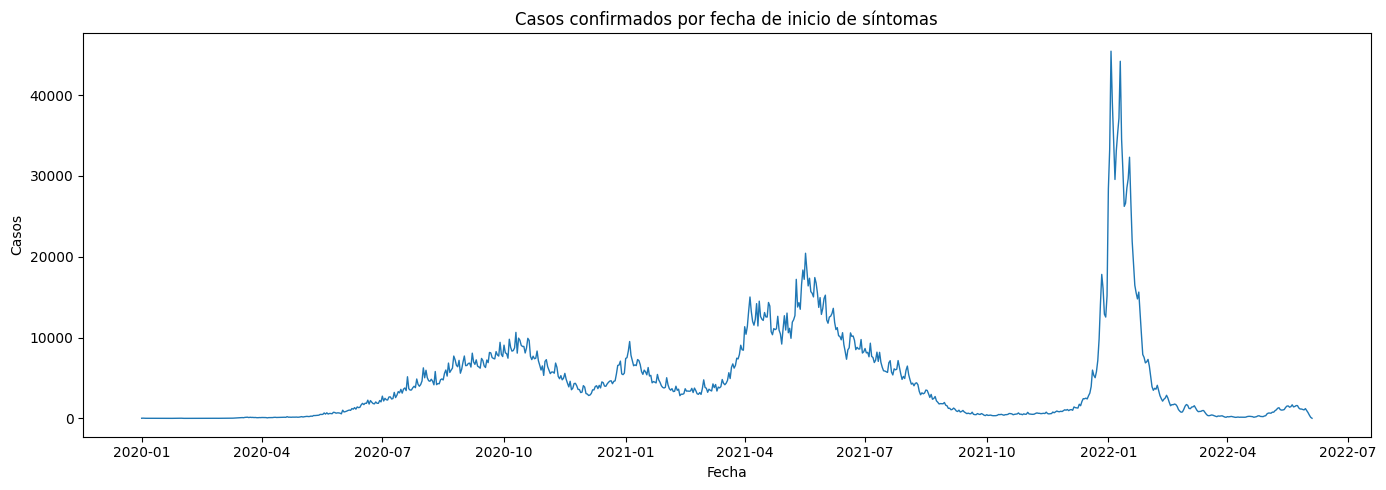

In [0]:
import matplotlib.pyplot as plt

pdf_casos_dia = spark.table("workspace.covid.gold_casos_por_dia").toPandas()
pdf_casos_dia = pdf_casos_dia.sort_values("fecha_inicio_sintomas")

plt.figure(figsize=(14, 5))
plt.plot(pdf_casos_dia["fecha_inicio_sintomas"], pdf_casos_dia["total_casos"], linewidth=1)
plt.title("Casos confirmados por fecha de inicio de síntomas")
plt.xlabel("Fecha")
plt.ylabel("Casos")
plt.tight_layout()
plt.show()

## Visualización: Mortalidad por franja etaria

La curva clásica de letalidad por COVID — el riesgo aumenta marcadamente con la edad.

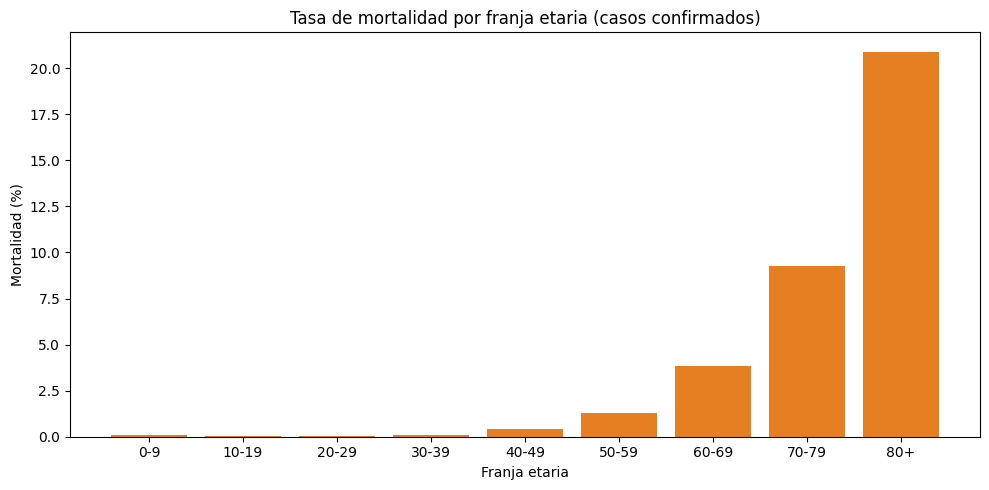

In [0]:
pdf_edad = spark.table("workspace.covid.gold_mortalidad_por_edad").toPandas()

plt.figure(figsize=(10, 5))
plt.bar(pdf_edad["franja_etaria"], pdf_edad["tasa_mortalidad_pct"], color="#e67e22")
plt.title("Tasa de mortalidad por franja etaria (casos confirmados)")
plt.xlabel("Franja etaria")
plt.ylabel("Mortalidad (%)")
plt.tight_layout()
plt.show()

## Gold: gold_edad_fallecidos

Distribución de la cantidad de fallecidos por edad — muestra en qué rango etario
se concentra la mayor cantidad de muertes en términos absolutos.

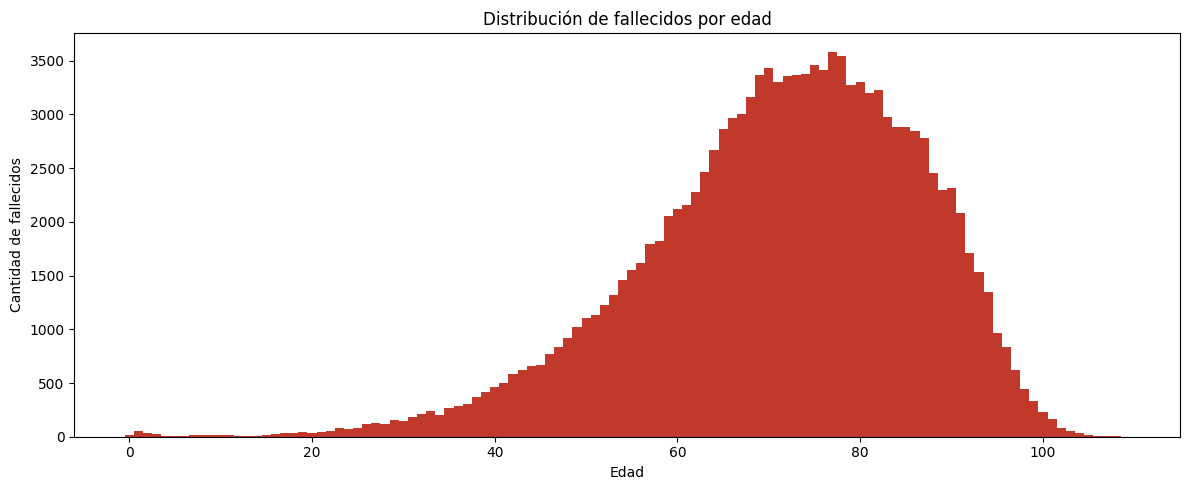

In [0]:
import matplotlib.pyplot as plt

pdf_edad_fallecidos = spark.table("workspace.covid.gold_edad_fallecidos").toPandas()

plt.figure(figsize=(12, 5))
plt.bar(pdf_edad_fallecidos["edad_anios"], pdf_edad_fallecidos["total_fallecidos"], color="#c0392b", width=1)
plt.title("Distribución de fallecidos por edad")
plt.xlabel("Edad")
plt.ylabel("Cantidad de fallecidos")
plt.tight_layout()
plt.show()

## Visualización: Mortalidad por provincia

Comparación de la tasa de letalidad entre provincias, ordenadas de mayor a menor.

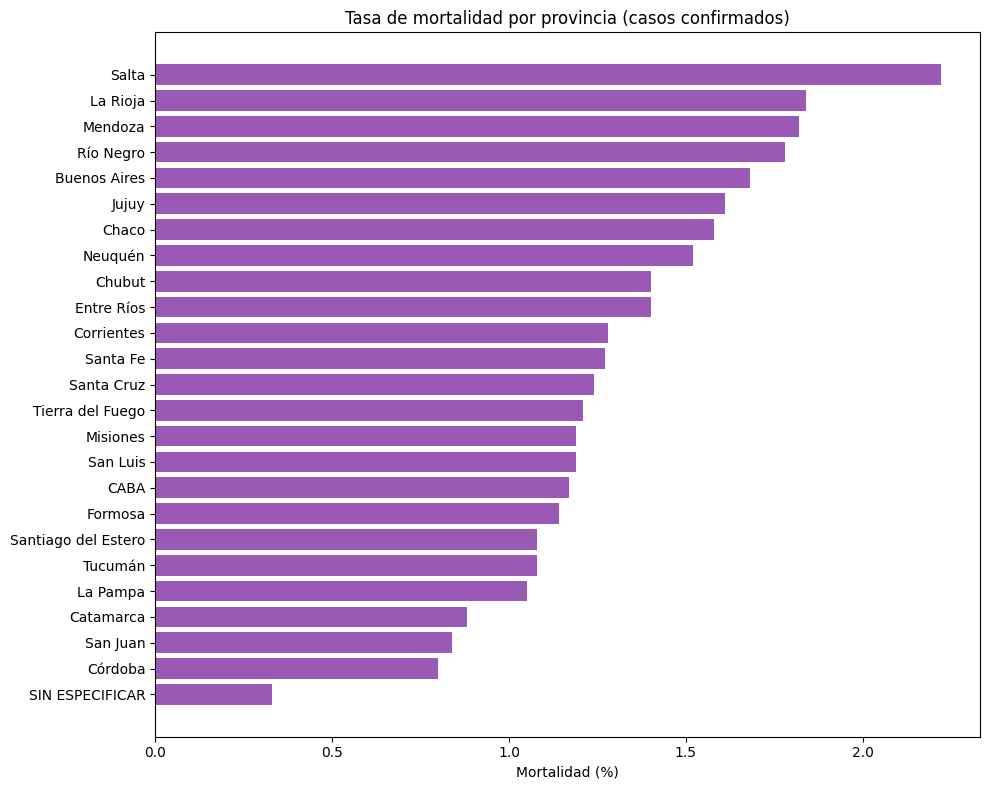

In [0]:
pdf_provincia = spark.table("workspace.covid.gold_resumen_provincia").toPandas()
pdf_provincia = pdf_provincia.sort_values("tasa_mortalidad_pct", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(pdf_provincia["provincia_nombre"], pdf_provincia["tasa_mortalidad_pct"], color="#9b59b6")
plt.title("Tasa de mortalidad por provincia (casos confirmados)")
plt.xlabel("Mortalidad (%)")
plt.tight_layout()
plt.show()

## Visualización: Demora promedio a diagnóstico por provincia

Días promedio entre el inicio de síntomas y el diagnóstico — un indicador de
capacidad de testeo por jurisdicción.

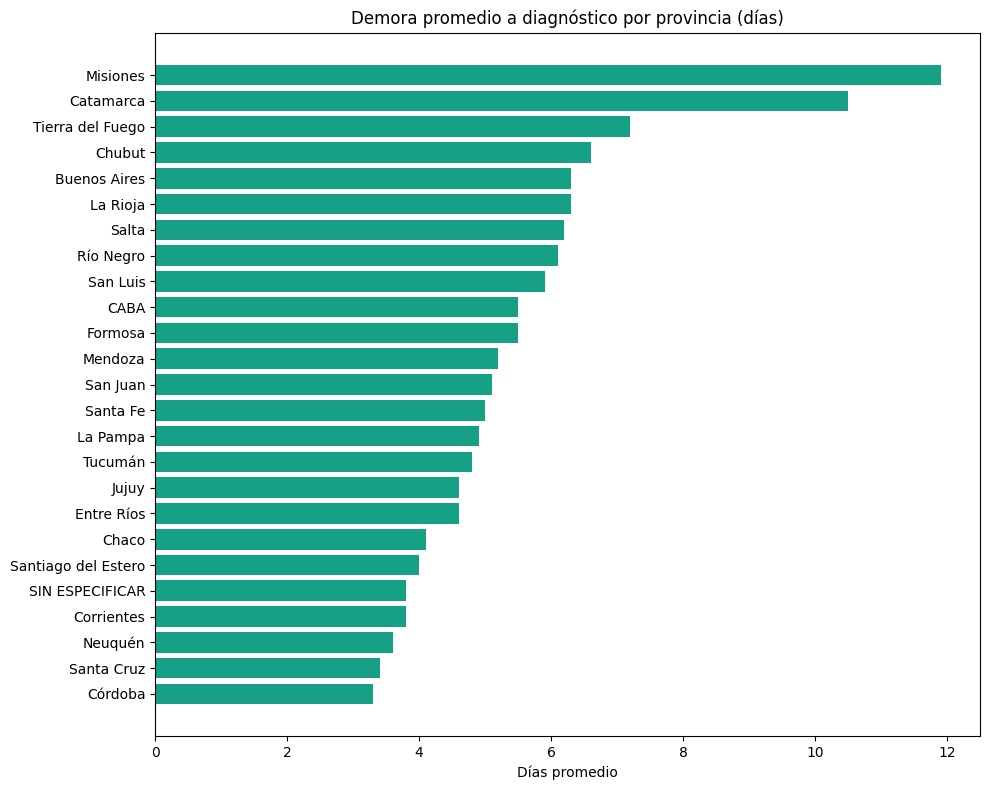

In [0]:
pdf_demoras = spark.table("workspace.covid.gold_demoras_sistema_salud").toPandas()
pdf_demoras = pdf_demoras.sort_values("promedio_dias_diagnostico", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(pdf_demoras["provincia_nombre"], pdf_demoras["promedio_dias_diagnostico"], color="#16a085")
plt.title("Demora promedio a diagnóstico por provincia (días)")
plt.xlabel("Días promedio")
plt.tight_layout()
plt.show()

## Visualización: Provincias por volumen de casos

Cantidad total de casos confirmados por provincia, ordenadas de menor a mayor. Se complementa
con el gráfico de mortalidad por provincia visto antes: cruzando ambos se puede distinguir
si una tasa de letalidad alta responde a una epidemia grande en esa provincia, o si se trata
de pocos casos confirmados con alta proporción de fallecidos (posible indicio de menor
capacidad de testeo, que deja afuera a los casos leves y concentra la detección en los
cuadros graves).

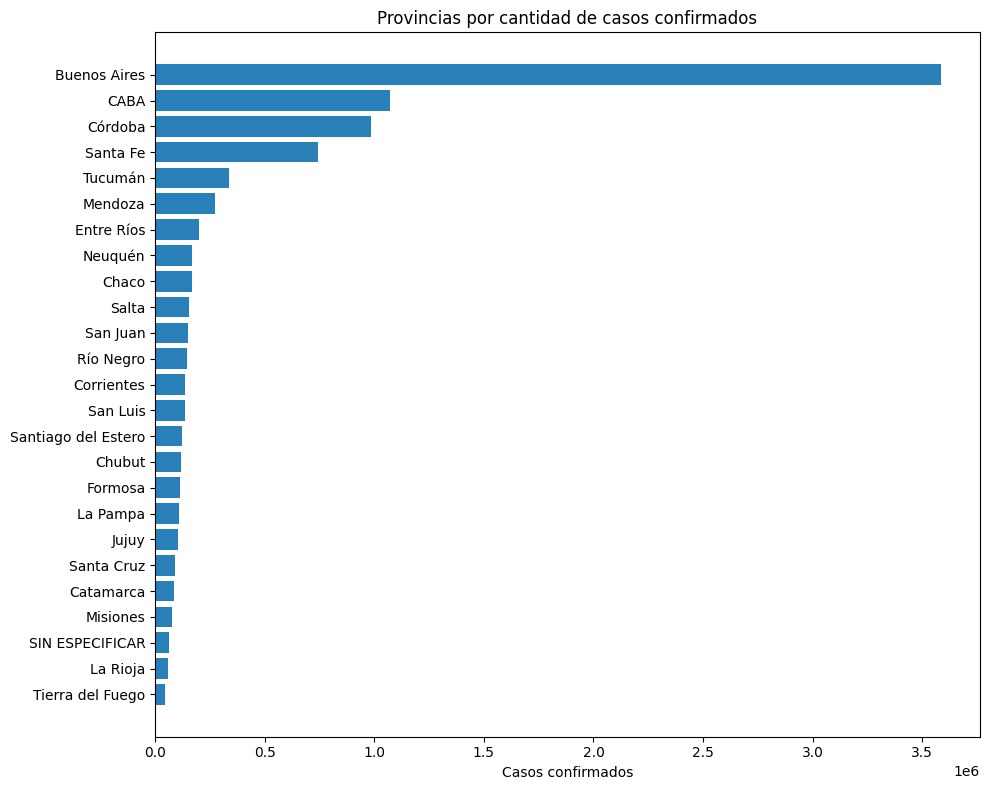

In [0]:
pdf_provincia = spark.table("workspace.covid.gold_resumen_provincia").toPandas()
pdf_provincia_top = pdf_provincia.sort_values("total_casos", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(pdf_provincia_top["provincia_nombre"], pdf_provincia_top["total_casos"], color="#2980b9")
plt.title("Provincias por cantidad de casos confirmados")
plt.xlabel("Casos confirmados")
plt.tight_layout()
plt.show()

## Visualización: Público vs. Privado

Comparación de severidad y mortalidad según el tipo de cobertura de salud, con tres métricas
en paralelo:

- **Mortalidad (%)**: tasa de letalidad sobre los casos confirmados de cada grupo.
- **Casos en UTI**: cantidad absoluta de pacientes que requirieron cuidados intensivos.
- **Total de casos**: volumen total de casos confirmados por tipo de financiamiento.

Mirar las tres juntas evita una lectura engañosa: una diferencia en la tasa de mortalidad
puede deberse a la gravedad real de los pacientes, pero también puede estar influida por el
volumen y el perfil de quién llega a cada sistema (por ejemplo, si el sector público
concentra más casos totales, incluyendo muchos leves, eso por sí solo puede diluir su tasa
de mortalidad frente al privado, aunque la calidad de atención sea comparable).

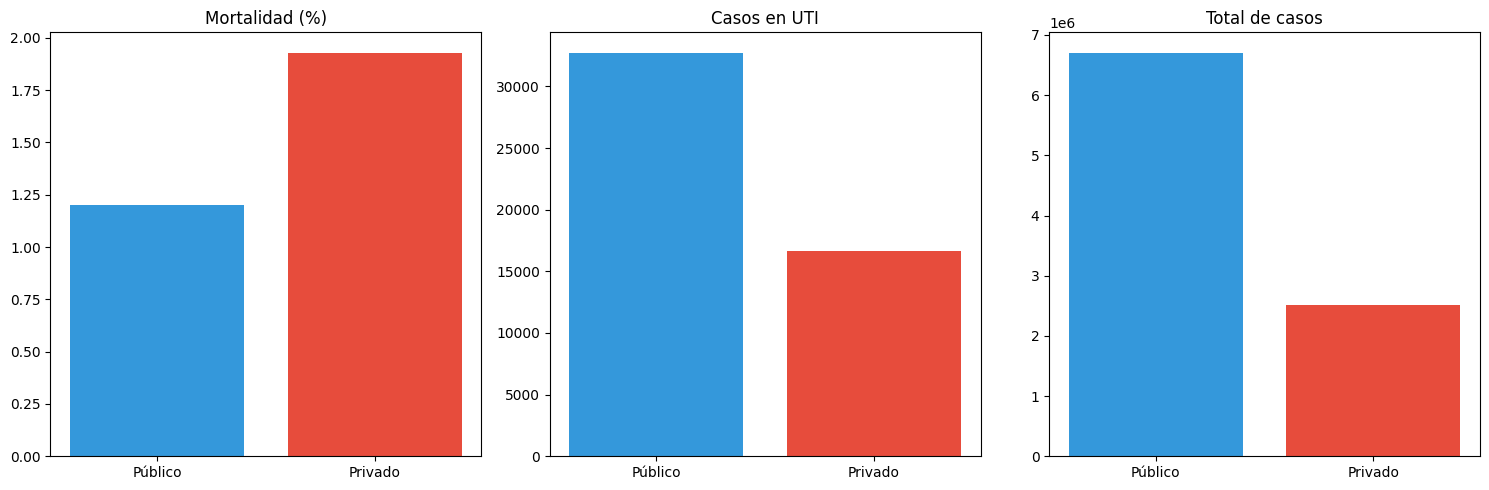

In [0]:
pdf_financiamiento = spark.table("workspace.covid.gold_publico_vs_privado").toPandas()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metricas = ["tasa_mortalidad_pct", "total_uti", "total_casos"]
titulos = ["Mortalidad (%)", "Casos en UTI", "Total de casos"]

for ax, metrica, titulo in zip(axes, metricas, titulos):
    ax.bar(pdf_financiamiento["origen_financiamiento"], pdf_financiamiento[metrica], color=["#3498db", "#e74c3c"])
    ax.set_title(titulo)

plt.tight_layout()
plt.show()

## Gold: gold_efectividad_uti_arm

Compara la tasa de mortalidad entre quienes requirieron UTI/ARM y quienes no,
para dimensionar la gravedad asociada a cada intervención (no mide "efectividad
del tratamiento" en sí, sino el perfil de riesgo de quien llega a necesitarlo).

- **UTI (Unidad de Terapia Intensiva)**: internación en cuidados críticos, reservada para
  pacientes con cuadros graves que requieren monitoreo y soporte constante.
- **ARM (Asistencia Respiratoria Mecánica)**: uso de respirador artificial, indicado cuando
  el paciente no puede sostener por sí mismo una oxigenación adecuada — generalmente el
  escalón más severo dentro de una internación en UTI.

Por eso ambos grupos muestran mortalidad más alta: no es que la UTI o el respirador "causen"
la muerte, sino que llegar a necesitarlos ya implica que el cuadro clínico es crítico.

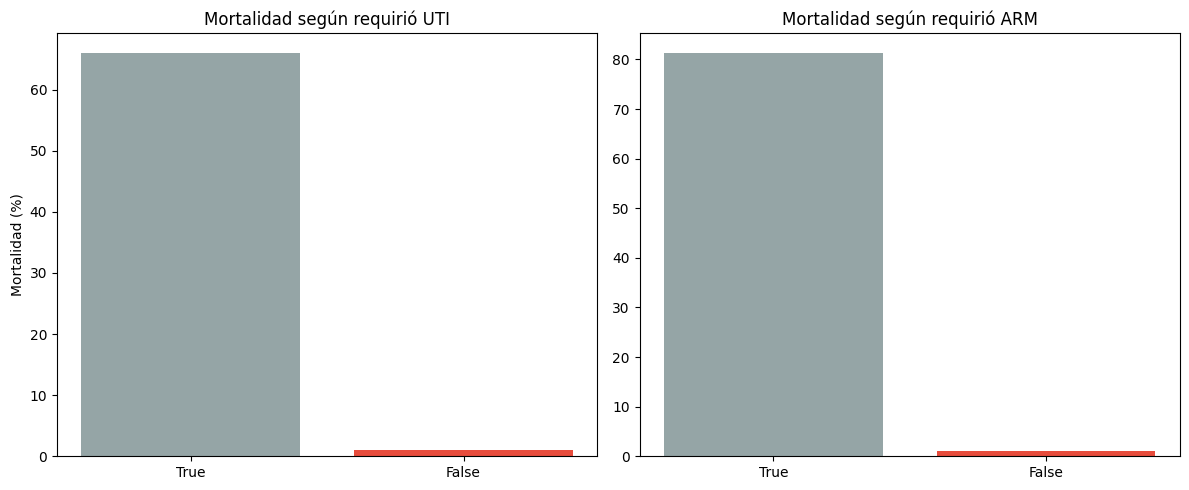

In [0]:
pdf_uti = spark.table("workspace.covid.gold_efectividad_uti").toPandas()
pdf_arm = spark.table("workspace.covid.gold_efectividad_arm").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(pdf_uti["requirio_uti"].astype(str), pdf_uti["tasa_mortalidad_pct"], color=["#95a5a6", "#e74c3c"])
axes[0].set_title("Mortalidad según requirió UTI")
axes[0].set_ylabel("Mortalidad (%)")

axes[1].bar(pdf_arm["requirio_arm"].astype(str), pdf_arm["tasa_mortalidad_pct"], color=["#95a5a6", "#e74c3c"])
axes[1].set_title("Mortalidad según requirió ARM")

plt.tight_layout()
plt.show()

## Visualización: Fallecidos vs. no fallecidos

Comparación simple entre el total de casos confirmados que fallecieron y los que no,
en valores absolutos — da una primera noción de magnitud antes de entrar en tasas
relativas por edad, provincia o tipo de cobertura.

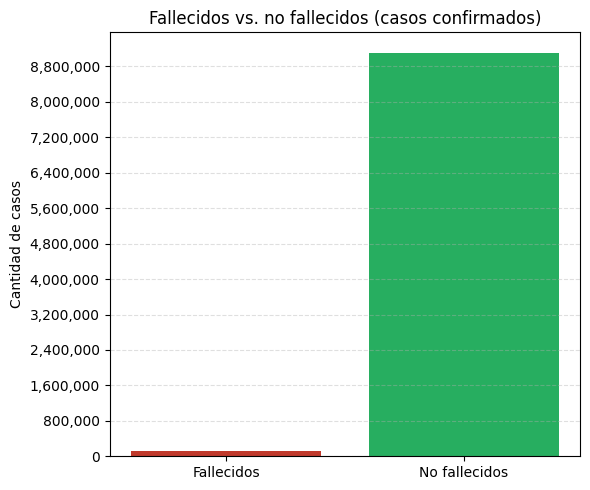

In [0]:
import matplotlib.ticker as mticker

pdf_kpis = spark.table("workspace.covid.gold_kpis_generales").toPandas()
no_fallecidos = pdf_kpis["total_confirmados"][0] - pdf_kpis["total_fallecidos"][0]

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(["Fallecidos", "No fallecidos"], [pdf_kpis["total_fallecidos"][0], no_fallecidos], color=["#c0392b", "#27ae60"])
ax.set_title("Fallecidos vs. no fallecidos (casos confirmados)")
ax.set_ylabel("Cantidad de casos")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=15))
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Visualización: Composición de fallecidos por sexo

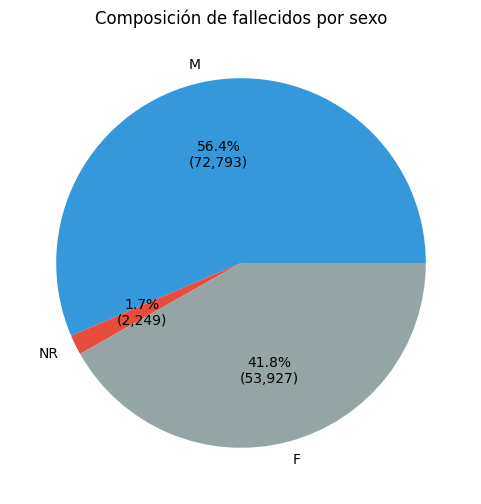

In [0]:
pdf_fallecidos_sexo = spark.table("workspace.covid.gold_composicion_fallecidos_sexo").toPandas()

total_fallecidos = pdf_fallecidos_sexo["total_fallecidos"].sum()

def autopct_con_valor(pct):
    valor = int(round(pct / 100 * total_fallecidos))
    return f"{pct:.1f}%\n({valor:,})"

plt.figure(figsize=(6, 6))
plt.pie(
    pdf_fallecidos_sexo["total_fallecidos"],
    labels=pdf_fallecidos_sexo["sexo"],
    autopct=autopct_con_valor,
    colors=["#3498db", "#e74c3c", "#95a5a6"]
)
plt.title("Composición de fallecidos por sexo")
plt.show()

## Gold: gold_letalidad_mensual

A diferencia de `gold_casos_por_dia` (que mide volumen), esta tabla agrupa los casos
confirmados por mes y calcula la tasa de mortalidad de cada período — permite ver si la
letalidad fue cambiando a lo largo de la pandemia (por ejemplo, cayendo con el avance de
la vacunación o con cepas de menor severidad), algo que el gráfico de volumen por sí solo
no muestra.

In [0]:
from pyspark.sql.functions import date_trunc, count, sum as spark_sum, round as spark_round

gold_letalidad_mensual = (
    confirmados
    .withColumn("mes", date_trunc("month", "fecha_inicio_sintomas"))
    .groupBy("mes")
    .agg(
        count("*").alias("total_casos"),
        spark_sum(col("fallecido").cast("int")).alias("total_fallecidos")
    )
    .withColumn("tasa_mortalidad_pct", spark_round(col("total_fallecidos") / col("total_casos") * 100, 2))
    .orderBy("mes")
)

gold_letalidad_mensual.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("workspace.covid.gold_letalidad_mensual")
gold_letalidad_mensual.show(24)

+-------------------+-----------+----------------+-------------------+
|                mes|total_casos|total_fallecidos|tasa_mortalidad_pct|
+-------------------+-----------+----------------+-------------------+
|               NULL|    5150878|           12639|               0.25|
|2020-01-01 00:00:00|        316|               8|               2.53|
|2020-02-01 00:00:00|        151|               8|                5.3|
|2020-03-01 00:00:00|       2121|             140|                6.6|
|2020-04-01 00:00:00|       3877|             361|               9.31|
|2020-05-01 00:00:00|      14256|             778|               5.46|
|2020-06-01 00:00:00|      46304|            2332|               5.04|
|2020-07-01 00:00:00|     104046|            5345|               5.14|
|2020-08-01 00:00:00|     173318|            7781|               4.49|
|2020-09-01 00:00:00|     217616|            9895|               4.55|
|2020-10-01 00:00:00|     255465|            9185|                3.6|
|2020-

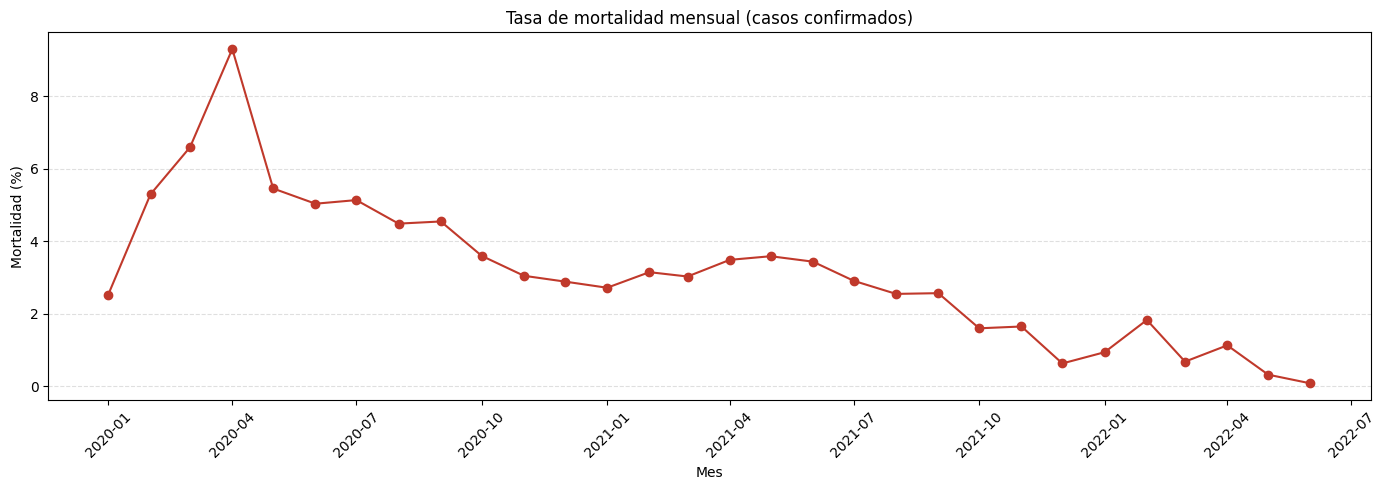

In [0]:
import matplotlib.ticker as mticker

pdf_letalidad_mensual = spark.table("workspace.covid.gold_letalidad_mensual").toPandas()
pdf_letalidad_mensual = pdf_letalidad_mensual.dropna(subset=["mes"]).sort_values("mes")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pdf_letalidad_mensual["mes"], pdf_letalidad_mensual["tasa_mortalidad_pct"], marker="o", linewidth=1.5, color="#c0392b")
ax.set_title("Tasa de mortalidad mensual (casos confirmados)")
ax.set_xlabel("Mes")
ax.set_ylabel("Mortalidad (%)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Gold: gold_casos_provincia_mes

Cruza provincia y mes para mostrar la intensidad de casos en un mapa de calor —
permite ver de un vistazo si las distintas olas de la pandemia golpearon a todas
las provincias al mismo tiempo, o si hubo desfasaje geográfico entre regiones.

In [0]:
dim_provincia = spark.table("workspace.covid.dim_provincia")

gold_casos_provincia_mes = (
    confirmados
    .withColumn("mes", date_trunc("month", "fecha_inicio_sintomas"))
    .join(dim_provincia, confirmados["provincia_id"] == dim_provincia["provincia_id"], "left")
    .groupBy("provincia_nombre", "mes")
    .agg(count("*").alias("total_casos"))
)

gold_casos_provincia_mes.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("workspace.covid.gold_casos_provincia_mes")
gold_casos_provincia_mes.show(10)

+----------------+-------------------+-----------+
|provincia_nombre|                mes|total_casos|
+----------------+-------------------+-----------+
|       Catamarca|2021-09-01 00:00:00|        211|
|        Misiones|2021-12-01 00:00:00|       2127|
|         Tucumán|2021-06-01 00:00:00|       3268|
|            CABA|2020-07-01 00:00:00|      21396|
|         Mendoza|2020-09-01 00:00:00|       7452|
|        La Rioja|2021-07-01 00:00:00|        204|
|         Neuquén|2020-01-01 00:00:00|         15|
|      Entre Ríos|2021-08-01 00:00:00|       4881|
|      Entre Ríos|2020-12-01 00:00:00|       7126|
|           Chaco|2021-04-01 00:00:00|        885|
+----------------+-------------------+-----------+
only showing top 10 rows


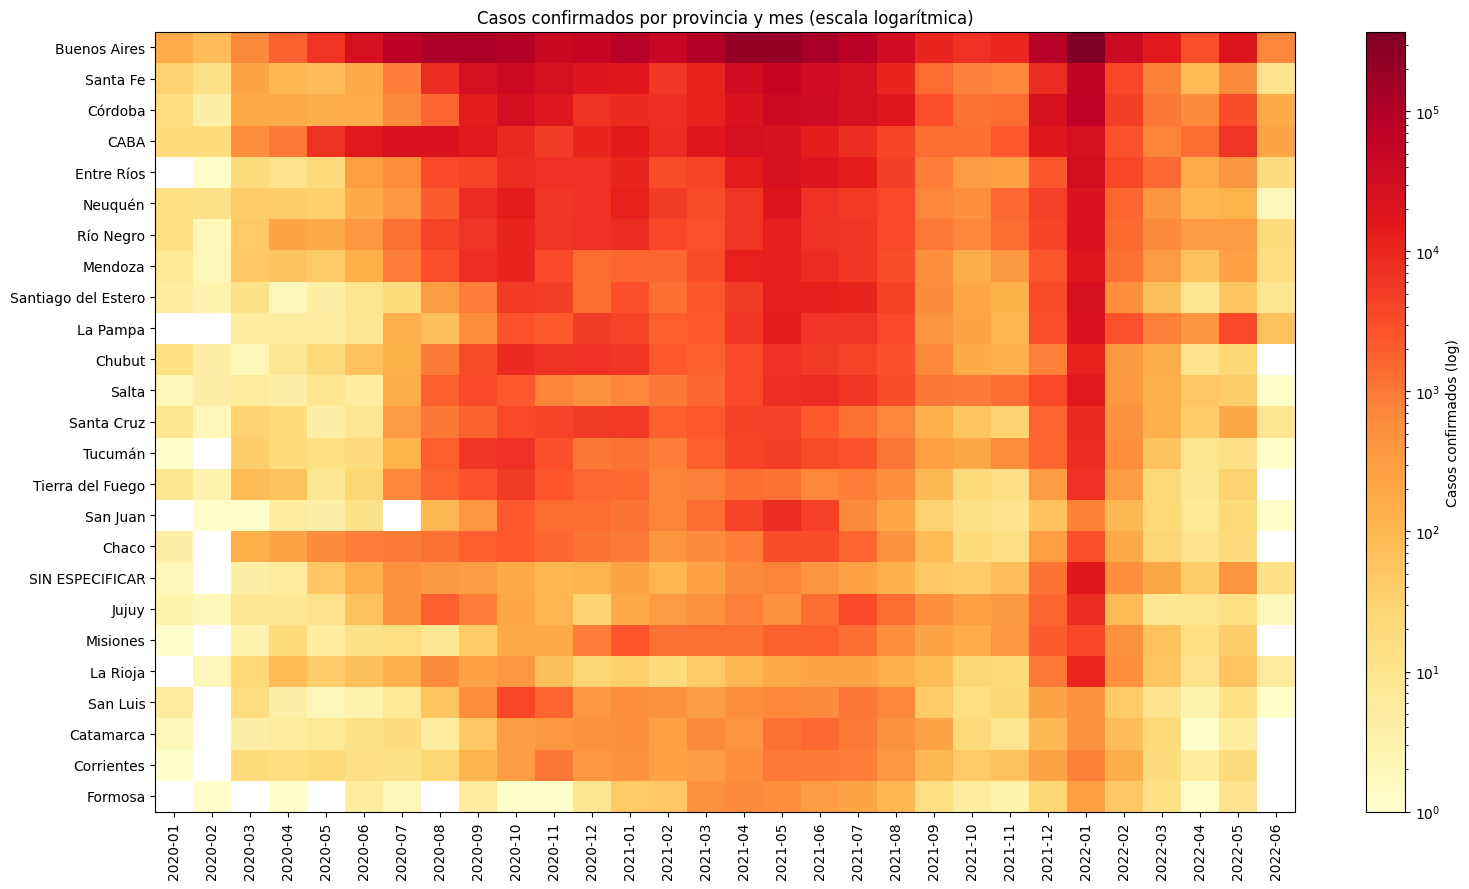

In [0]:
import numpy as np
import matplotlib.colors as mcolors

pdf_heatmap = spark.table("workspace.covid.gold_casos_provincia_mes").toPandas()
pdf_heatmap = pdf_heatmap.dropna(subset=["mes"])

pivot = pdf_heatmap.pivot_table(index="provincia_nombre", columns="mes", values="total_casos", fill_value=0)
pivot = pivot.reindex(pivot.sum(axis=1).sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(16, 9))
im = ax.imshow(
    pivot.values,
    aspect="auto",
    cmap="YlOrRd",
    norm=mcolors.LogNorm(vmin=max(pivot.values[pivot.values > 0].min(), 1), vmax=pivot.values.max())
)

ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([d.strftime("%Y-%m") for d in pivot.columns], rotation=90)

ax.set_title("Casos confirmados por provincia y mes (escala logarítmica)")
fig.colorbar(im, ax=ax, label="Casos confirmados (log)")
plt.tight_layout()
plt.show()

## Gold: gold_piramide_edad

Compara, por franja etaria, qué porcentaje del total de casos confirmados representa
cada grupo contra qué porcentaje del total de fallecidos representa ese mismo grupo.
Deja ver el contraste central de la pandemia: la mayoría de los contagios ocurrieron
en población joven/adulta, pero la mayoría de las muertes se concentraron en adultos
mayores.

In [0]:
from pyspark.sql.functions import floor, concat, lit

con_franja = confirmados.withColumn(
    "franja_etaria",
    concat((floor(col("edad_anios") / 10) * 10).cast("string"), lit("-"), ((floor(col("edad_anios") / 10) * 10) + 9).cast("string"))
).filter(col("edad_anios").isNotNull())

casos_por_franja = con_franja.groupBy("franja_etaria").agg(count("*").alias("total_casos"))
fallecidos_por_franja = con_franja.filter(col("fallecido")).groupBy("franja_etaria").agg(count("*").alias("total_fallecidos"))

total_casos_gral = casos_por_franja.agg(spark_sum("total_casos")).collect()[0][0]
total_fallecidos_gral = fallecidos_por_franja.agg(spark_sum("total_fallecidos")).collect()[0][0]

gold_piramide_edad = (
    casos_por_franja.join(fallecidos_por_franja, "franja_etaria", "left")
    .fillna(0, subset=["total_fallecidos"])
    .withColumn("pct_casos", spark_round(col("total_casos") / total_casos_gral * 100, 2))
    .withColumn("pct_fallecidos", spark_round(col("total_fallecidos") / total_fallecidos_gral * 100, 2))
)

gold_piramide_edad.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable("workspace.covid.gold_piramide_edad")
gold_piramide_edad.orderBy("franja_etaria").show(20)

+-------------+-----------+----------------+---------+--------------+
|franja_etaria|total_casos|total_fallecidos|pct_casos|pct_fallecidos|
+-------------+-----------+----------------+---------+--------------+
|          0-9|     226668|             198|     2.45|          0.15|
|        10-19|     678572|             202|     7.34|          0.16|
|      100-109|       1780|             604|     0.02|          0.47|
|      110-119|         49|               0|      0.0|           0.0|
|      120-129|          5|               0|      0.0|           0.0|
|        20-29|    1956597|             902|    21.17|           0.7|
|        30-39|    2155568|            2641|    23.32|          2.05|
|        40-49|    1777064|            7030|    19.23|          5.45|
|        50-59|    1170203|           15090|    12.66|         11.71|
|        60-69|     708541|           27053|     7.67|         20.99|
|        70-79|     369057|           34113|     3.99|         26.47|
|        80-89|     

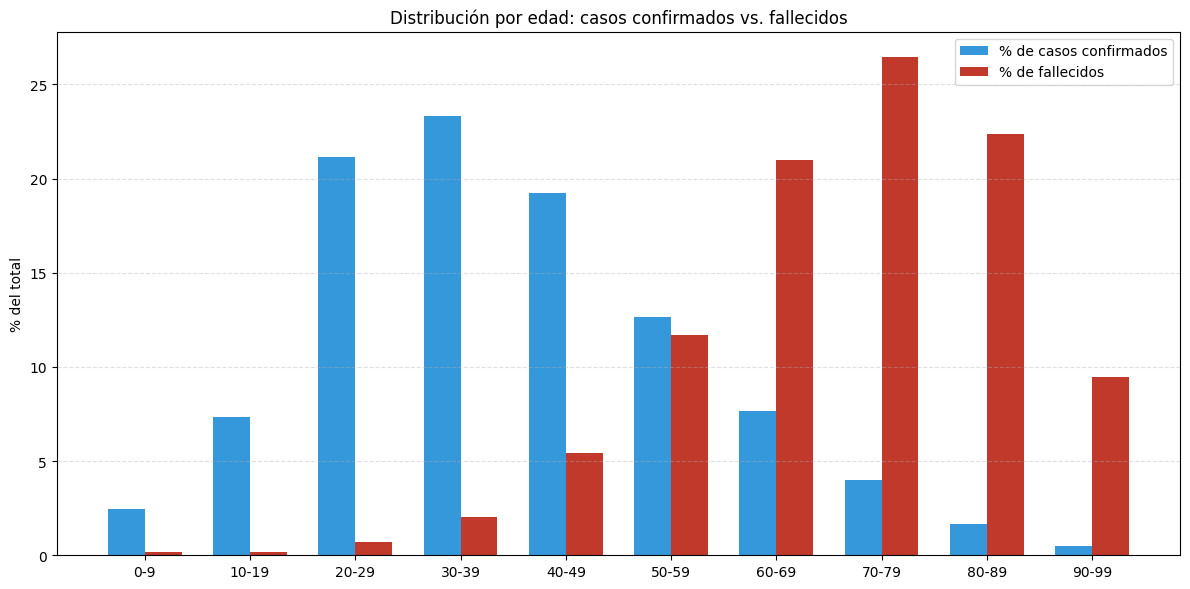

In [0]:
import numpy as np
import matplotlib.pyplot as plt

pdf_piramide = spark.table("workspace.covid.gold_piramide_edad").toPandas()

pdf_piramide["edad_inicio"] = pdf_piramide["franja_etaria"].str.split("-").str[0].astype(int)
pdf_piramide = pdf_piramide[pdf_piramide["edad_inicio"] <= 90].sort_values("edad_inicio")

x = np.arange(len(pdf_piramide))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, pdf_piramide["pct_casos"], width, label="% de casos confirmados", color="#3498db")
ax.bar(x + width/2, pdf_piramide["pct_fallecidos"], width, label="% de fallecidos", color="#c0392b")

ax.set_xticks(x)
ax.set_xticklabels(pdf_piramide["franja_etaria"])
ax.set_ylabel("% del total")
ax.set_title("Distribución por edad: casos confirmados vs. fallecidos")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Visualización: Demora a diagnóstico vs. mortalidad por provincia

Cruza `gold_demoras_sistema_salud` y `gold_resumen_provincia` en un único gráfico de
dispersión — cada punto es una provincia. Permite explorar si diagnosticar tarde se
asocia con mayor letalidad, o si ambas métricas son independientes entre sí.

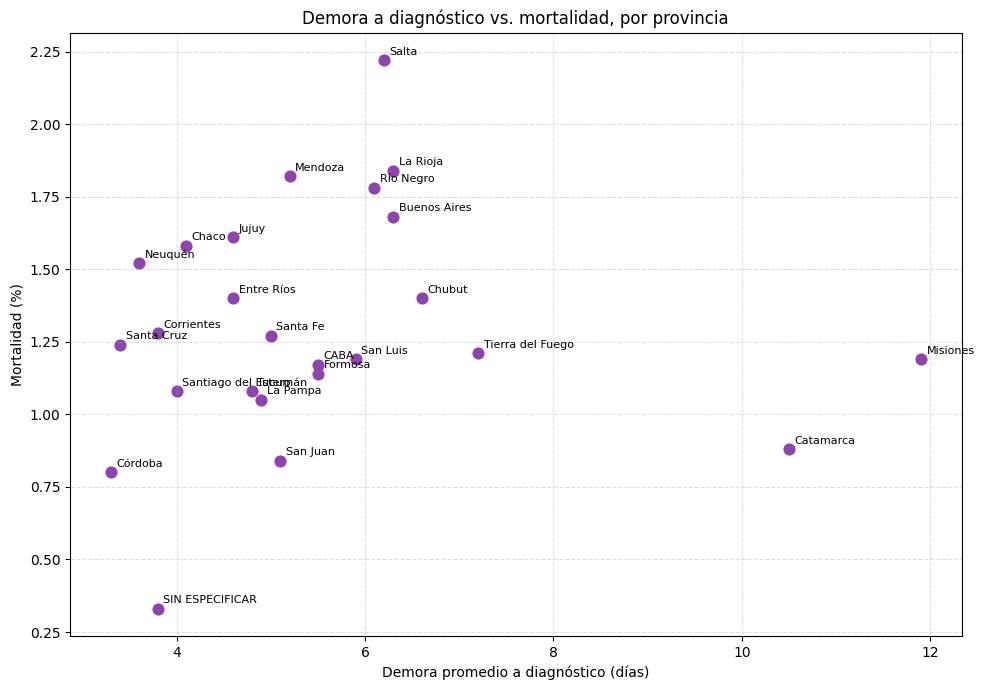

In [0]:
pdf_demoras = spark.table("workspace.covid.gold_demoras_sistema_salud").toPandas()
pdf_provincia_resumen = spark.table("workspace.covid.gold_resumen_provincia").toPandas()

pdf_provincia_resumen = pdf_provincia_resumen.drop(columns=["promedio_dias_diagnostico"])

pdf_cruce = pdf_demoras.merge(pdf_provincia_resumen, on="provincia_nombre")

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(pdf_cruce["promedio_dias_diagnostico"], pdf_cruce["tasa_mortalidad_pct"], color="#8e44ad", s=60)

for _, row in pdf_cruce.iterrows():
    ax.annotate(row["provincia_nombre"], (row["promedio_dias_diagnostico"], row["tasa_mortalidad_pct"]), fontsize=8, xytext=(4, 4), textcoords="offset points")

ax.set_xlabel("Demora promedio a diagnóstico (días)")
ax.set_ylabel("Mortalidad (%)")
ax.set_title("Demora a diagnóstico vs. mortalidad, por provincia")
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()